## Installations
---

In [1]:
%%capture

!pip install -q gdown segmentation-models-pytorch albumentations
!pip install -q transformers torchgeo grad-cam

### Import Libraries
---

In [2]:
import os
import json
import random
import zipfile

from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp
from transformers import SegformerForSemanticSegmentation, SegformerConfig
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from tqdm import tqdm

In [3]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

DEVICE

'cuda'

## Configurations
---

In [4]:
CFG = {
    "arch" : "segformer",
    "init" : "imagenet",

    "run_version" : "v1",
    "img_size" : 512,
    "batch_size" : 4,
    "epochs" : 40,
    "patience" : 8,
    "lr_encoder" : 1e-5,
    "lr_decoder" : 3e-4,
    "weight_decay" : 1e-4,
    "seed" : 42,
    "dice_weight" : 0.7,
    "ce_weight" : 0.3,
    "threshold" : 0.5,
    "dup_hamming" : 5
}

In [5]:
CFG['run_id'] = f"{CFG['arch']}-{CFG['init']}"

CFG

{'arch': 'segformer',
 'init': 'imagenet',
 'run_version': 'v1',
 'img_size': 512,
 'batch_size': 4,
 'epochs': 40,
 'patience': 8,
 'lr_encoder': 1e-05,
 'lr_decoder': 0.0003,
 'weight_decay': 0.0001,
 'seed': 42,
 'dice_weight': 0.7,
 'ce_weight': 0.3,
 'threshold': 0.5,
 'dup_hamming': 5,
 'run_id': 'segformer-imagenet'}

- Seeding (Randomness)

In [6]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

In [7]:
set_seed(CFG['seed'])

## Download Dataset
---

In [8]:
file_id = "114xnPVZtthHi4Bejzho33vGJSqb4-F8g"
output_zip = "/content/dataset.zip"
extract_path = Path("/content/flopwd_data")

In [9]:
!gdown --id {file_id} -O {output_zip}

if os.path.exists(output_zip):
    os.makedirs(extract_path, exist_ok=True)
    with zipfile.ZipFile(output_zip, "r") as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"Success! Dataset extracted to {extract_path}")

/usr/local/lib/python3.13/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=114xnPVZtthHi4Bejzho33vGJSqb4-F8g
From (redirected): https://drive.google.com/uc?id=114xnPVZtthHi4Bejzho33vGJSqb4-F8g&confirm=t&uuid=1bfbaa75-c603-41c8-916b-8bc07853ef15
To: /content/dataset.zip
100% 358M/358M [00:05<00:00, 71.6MB/s]
Success! Dataset extracted to /content/flopwd_data


## Import Dataset
---

In [10]:
dataset_path = extract_path / "Dal Lake Floating Plastic Waste Detection Dataset (FloPWD 2025)"
raw_dir = dataset_path / "Raw_Images"
mask_dir = dataset_path / "Segmentation_Masks"
labels_csv = dataset_path / "Image_labels_Binary Classification Task.csv"
reg_csv = dataset_path / "Mask_foreground_percentages_Regression Task.csv"

In [11]:
"images:", len(list(raw_dir.glob("*.jpg")))

('images:', 2002)

In [12]:
"masks :", len(list(mask_dir.glob("*.png")))

('masks :', 2002)

### Build Dataframe

In [13]:
labels_df = pd.read_csv(labels_csv)

labels_df = labels_df.rename(columns={
    "image name" : "image_name",
    "Presence of plastic waste?" : "presence"
})

In [14]:
reg_df = pd.read_csv(reg_csv)

reg_df = reg_df.rename(columns={
    "image name" : "image_name",
    "plastic waste accumulation (in percentage)" : "fg_pct"
})

- merge

In [15]:
df = labels_df.merge(reg_df, on="image_name", how="inner")

df['image_path'] = df['image_name'].apply(lambda x: str(raw_dir / x))
df['mask_path'] = df['image_name'].str.replace('.jpg', "_mask.png", regex=False).apply(lambda x: str(mask_dir / x))
df['has_plastic'] = (df['presence'].astype(str).str.lower() == 'yes').astype(int)
df['fg_pct'] = df['fg_pct'].astype(float)

In [16]:
df.head()

,image_name,presence,fg_pct,image_path,mask_path,has_plastic
0,img1.jpg,yes,0.08,/content/flopwd_data/Dal Lake Floating Plastic...,/content/flopwd_data/Dal Lake Floating Plastic...,1
1,img2.jpg,yes,0.03,/content/flopwd_data/Dal Lake Floating Plastic...,/content/flopwd_data/Dal Lake Floating Plastic...,1
2,img3.jpg,yes,0.38,/content/flopwd_data/Dal Lake Floating Plastic...,/content/flopwd_data/Dal Lake Floating Plastic...,1
3,img4.jpg,yes,0.20,/content/flopwd_data/Dal Lake Floating Plastic...,/content/flopwd_data/Dal Lake Floating Plastic...,1
4,img5.jpg,yes,0.18,/content/flopwd_data/Dal Lake Floating Plastic...,/content/flopwd_data/Dal Lake Floating Plastic...,1


### EDA
---

In [17]:
r = df.iloc[0]
img = cv2.cvtColor(cv2.imread(r['image_path']), cv2.COLOR_BGR2RGB)
mask = (cv2.imread(r['mask_path'], cv2.IMREAD_GRAYSCALE) > 127).astype(np.uint8)

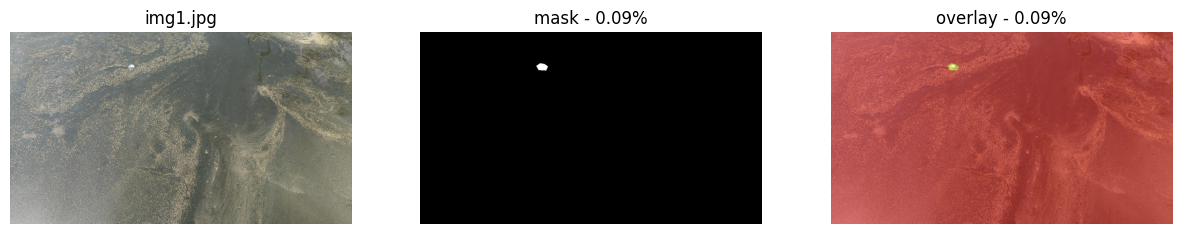

In [18]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].imshow(img)
ax[0].set_title(r['image_name'])

ax[1].imshow(mask, cmap='gray')
ax[1].set_title(f'mask - {mask.mean()*100:.2f}%')

ax[2].imshow(img)
ax[2].imshow(mask, alpha=0.4, cmap='autumn')
ax[2].set_title(f'overlay - {mask.mean()*100:.2f}%')

for a in ax:
    a.axis('off')

## Split
---

In [19]:
train_val_df, test_df = train_test_split(df, test_size=0.15, random_state=CFG['seed'], stratify=df['has_plastic'])

In [20]:
train_df, val_df = train_test_split(train_val_df, test_size=15/85, random_state=CFG['seed'], stratify=train_val_df['has_plastic'])

In [21]:
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [22]:
len(train_df), len(val_df), len(test_df)

(1400, 301, 301)

## Image Augmentation
---

In [23]:
S = CFG['img_size']
MEAN = (0.485, 0.456, 0.406)
STD = (0.229, 0.224, 0.225)

In [24]:
train_tf = A.Compose([
    A.Resize(S, S),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=30, p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.4),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2()
])

/usr/local/lib/python3.13/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [25]:
eval_tf = A.Compose([
    A.Resize(S, S),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2()
])

## Training - Dataset
---

In [26]:
class FloPWD(Dataset):

    def __init__(self, frame, tf):
        self.df, self.tf = frame, tf

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        r = self.df.iloc[i]
        img = cv2.cvtColor(cv2.imread(r['image_path']), cv2.COLOR_BGR2RGB)
        mask = (cv2.imread(r['mask_path'], cv2.IMREAD_GRAYSCALE) > 127).astype(np.uint8)
        out = self.tf(image=img, mask=mask)
        return out['image'], out['mask'].long()

## Training - DataLoader
---

In [27]:
B = CFG['batch_size']

In [28]:
train_loader = DataLoader(FloPWD(train_df, train_tf), batch_size=B, shuffle=True, num_workers=0, pin_memory=True, drop_last=True)
val_loader = DataLoader(FloPWD(val_df, eval_tf), batch_size=B, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(FloPWD(test_df, eval_tf), batch_size=B, shuffle=False, num_workers=0, pin_memory=True)

## Model
---

In [29]:
ARCH = {
    "unet" : smp.Unet,
    "deeplab" : smp.DeepLabV3Plus,
    "unetpp" : smp.UnetPlusPlus,
    "upernet" : smp.UPerNet
}

In [30]:
def build_model(arch, init):
    if arch in ARCH:
        enc = "tu-convnextv2_nano" if arch == "upernet" else "resnet50"
        model = ARCH[arch](
            encoder_name = enc,
            encoder_weights = "imagenet" if init == "imagenet" else None,
            classes = 2
        )

        if init == "aerial":
            from torchgeo.models import ResNet50_Weights
            sd = ResNet50_Weights.FMOW_RGB_GASSL.get_state_dict(progress=True)
            missing, unexpected = model.encoder.load_state_dict(sd, strict=False)

        return model

    src = {
        "raw" : None,
        "imagenet" : "nvidia/mit-b3",
        "aerial" : "chribark/segformer-b3-finetuned-UAVid"
    }

    src = src[init]

    if src is None:
        cfg = SegformerConfig.from_pretrained("nvidia/mit-b3", num_labels=2)

        return SegformerForSemanticSegmentation(cfg)

    return SegformerForSemanticSegmentation.from_pretrained(src, num_labels=2, ignore_mismatched_sizes=True)

In [31]:
model = build_model(CFG['arch'], CFG['init']).to(DEVICE)

config.json:   0%|          | 0.00/70.0k [00:00<?, ?B/s]

[transformers] You passed `num_labels=2` which is incompatible to the `id2label` map of length `1000`.


pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  179MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/628 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  178MB            

model.safetensors: downloading bytes:           |  0.00B            

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b3
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
classifier.bias                                         | UNEXPECTED | 
classifier.weight                                       | UNEXPECTED | 
decode_head.classifier.weight                           | MISSING    | 
decode_head.linear_fuse.weight                          | MISSING    | 
decode_head.batch_norm.weight                           | MISSING    | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.classifier.bias                             | MISSING    | 
decode_head.batch_norm.bias                             | MISSING    | 
decode_head.batch_norm.running_mean                     | MISSING    | 
decode_head.batch_norm.num_batches_tracked              

### Weight Fingerprint
---

In [32]:
p = next(model.parameters())

In [33]:
f"{CFG['run_id']:24s} mean={float(p.mean()):+.6f}  std={float(p.std()):.6f}"

/tmp/ipykernel_3442/2017929731.py:1: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  f"{CFG['run_id']:24s} mean={float(p.mean()):+.6f}  std={float(p.std()):.6f}"


'segformer-imagenet       mean=-0.000003  std=0.054351'

In [34]:
"parameters:", round(sum(q.numel() for q in model.parameters()) / 1e6, 2), "M"

('parameters:', 47.22, 'M')

## Loss
---

In [35]:
sub = train_df.sample(
    min(200, len(train_df)),
    random_state=CFG['seed']
)

pos = 0
neg = 0

In [36]:
for _, r in sub.iterrows():
    mask = cv2.imread(r["mask_path"], cv2.IMREAD_GRAYSCALE) > 127
    pos += int(mask.sum())
    neg += int(mask.size - mask.sum())

In [37]:
pos_weight = neg / max(pos, 1)

pos_weight

18.368890673898054

### Dice Loss
---

In [38]:
def dice_loss(logits, targets, smooth=1.0):
    probs = torch.softmax(logits, dim=1)[:, 1]
    t = targets.float()
    inter = (probs * t).sum(dim=(1, 2))
    union = probs.sum(dim=(1, 2)) + t.sum(dim=(1, 2))
    return 1.0 - ((2 * inter + smooth) / (union + smooth)).mean()

### Criterion
---

In [39]:
w  = torch.tensor([1.0, float(min(pos_weight, 50.0))], device=DEVICE)
ce = nn.CrossEntropyLoss(weight=w)

In [40]:
def criterion(logits, targets):
    return CFG["dice_weight"] * dice_loss(logits, targets) + CFG["ce_weight"] * ce(logits, targets)

## Optimizer
---

In [41]:
if CFG['arch'] == 'segformer':
    enc = list(model.segformer.parameters())
    dec = list(model.decode_head.parameters())
else:
    enc = list(model.encoder.parameters())
    dec = [q for n, q in model.named_parameters() if not n.startswith('encoder.')]

In [42]:
lr_enc = CFG["lr_decoder"] if CFG["init"] == "raw" else CFG["lr_encoder"]

In [43]:
optimizer = torch.optim.AdamW(
    [{"params": enc, "lr": lr_enc}, {"params": dec, "lr": CFG["lr_decoder"]}],
    weight_decay=CFG["weight_decay"
])

In [44]:
scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE == "cuda"))

## Training
---

### Forward Pass

In [45]:
def forward_logits(model, x):
    out = model(x)

    if hasattr(out, "logits"):
        return F.interpolate(out.logits, size=x.shape[-2:], mode='bilinear', align_corners=False)

    return out

### Metrics

In [46]:
def compute_stats(preds, targets, eps=1e-7):
    p, t = preds.float(), targets.float()
    tp = (p * t).sum(dim=(1, 2))
    fp = (p * (1 - t)).sum(dim=(1, 2))
    fn = ((1 - p) * t).sum(dim=(1, 2))
    tn = ((1 - p) * (1 - t)).sum(dim=(1, 2))
    fg = (tp + eps) / (tp + fp + fn + eps)
    bg = (tn + eps) / (tn + fp + fn + eps)

    return {"foreground_iou": fg, "background_iou": bg, "miou": (fg + bg) / 2,
            "dice": (2*tp + eps) / (2*tp + fp + fn + eps),
            "precision": (tp + eps) / (tp + fp + eps),
            "recall":    (tp + eps) / (tp + fn + eps)
    }

### Epoch

In [47]:
def train_epoch():
    model.train()

    total = 0.0
    for x, y in tqdm(train_loader, desc='train', leave=False):
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda", enabled=(DEVICE == "cuda")):
            loss = criterion(forward_logits(model, x), y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total += loss.item()

    return total / len(train_loader)

In [48]:
@torch.no_grad()
def evaluate(loader):
    model.eval()

    acc = {}
    total = 0.0
    for x, y in tqdm(loader, desc="eval", leave=False):
        x, y = x.to(DEVICE), y.to(DEVICE)

        logits = forward_logits(model, x)

        total += criterion(logits, y).item()

        pred = (torch.softmax(logits, dim=1)[:, 1] > CFG["threshold"]).float()

        for k, v in compute_stats(pred, y).items():
            acc.setdefault(k, []).append(v.cpu())

    res = {k: float(torch.cat(v).mean()) for k, v in acc.items()}

    res["loss"] = total / len(loader)

    return res

### Main Loop

In [50]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [51]:
OUT = Path(f"/content/drive/MyDrive/THESIS/runs/{CFG['run_id']}/{CFG['run_version']}")
OUT.mkdir(parents=True, exist_ok=True)
best_path = OUT / "best.pth"

In [52]:
best, bad, history = -1.0, 0, []

for ep in range(1, CFG["epochs"] + 1):
    tr = train_epoch()

    va = evaluate(val_loader)

    history.append({"epoch": ep, "train_loss": tr, **{f"val_{k}": v for k, v in va.items()}})

    if va["miou"] > best:
        best, bad = va["miou"], 0
        torch.save(model.state_dict(), best_path)
        print(f"saved (mIoU {best:.4f})")
    else:
        bad += 1
        if bad >= CFG["patience"]:
            print(f"early stop at epoch {ep}")
            break

saved (mIoU 0.6784)


saved (mIoU 0.7487)


saved (mIoU 0.7544)


saved (mIoU 0.7713)


saved (mIoU 0.7810)


...

saved (mIoU 0.8055)


saved (mIoU 0.8059)


saved (mIoU 0.8083)


saved (mIoU 0.8084)


saved (mIoU 0.8164)


In [53]:
pd.DataFrame(history).to_csv(OUT / "history.csv", index=False)

In [54]:
train_df[["image_name"]].assign(split="train").to_csv(OUT / "split_train.csv", index=False)
val_df[["image_name"]].assign(split="val").to_csv(OUT / "split_val.csv", index=False)
test_df[["image_name"]].assign(split="test").to_csv(OUT / "split_test.csv", index=False)

## Results
---

In [55]:
model.load_state_dict(torch.load(best_path, map_location=DEVICE))


<All keys matched successfully>

In [56]:
res = evaluate(test_loader)

In [57]:
res.update({"run_id": CFG["run_id"], "version": CFG["run_version"],
            "best_val_miou": best, "n_train": len(train_df),
            "n_val": len(val_df), "n_test": len(test_df), "cfg": CFG})

In [58]:
with open(OUT / "test_metrics.json", "w") as f:
    json.dump(res, f, indent=2)

print(json.dumps({k: round(v, 4) for k, v in res.items() if isinstance(v, float)}, indent=2))

{
  "foreground_iou": 0.6746,
  "background_iou": 0.9675,
  "miou": 0.821,
  "dice": 0.772,
  "precision": 0.7847,
  "recall": 0.8216,
  "loss": 0.2374,
  "best_val_miou": 0.8164
}


### Samples

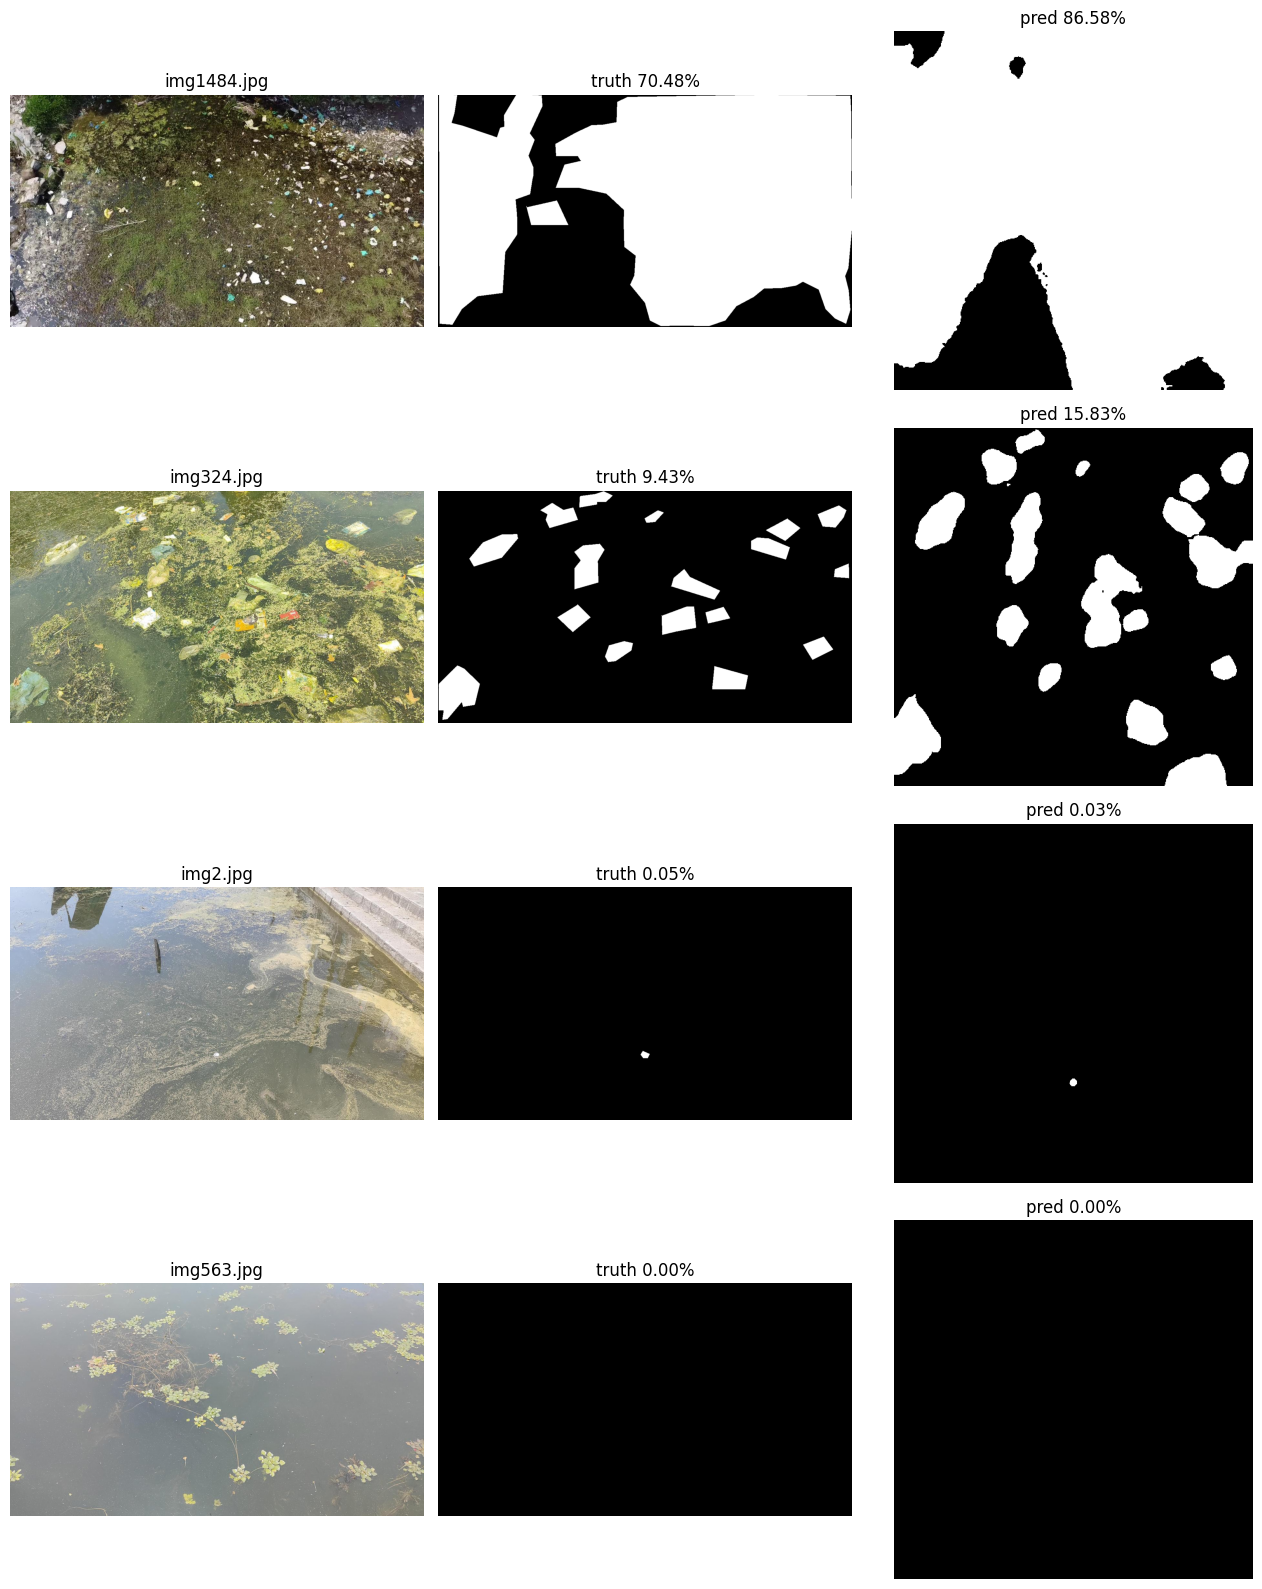

In [59]:
SAMPLES = ["img1484.jpg", "img324.jpg", "img2.jpg", "img563.jpg"]
rows = [df[df.image_name == n].iloc[0] for n in SAMPLES]

fig, ax = plt.subplots(len(rows), 3, figsize=(13, 4 * len(rows)))

for i, r in enumerate(rows):
    img = cv2.cvtColor(cv2.imread(r["image_path"]), cv2.COLOR_BGR2RGB)

    gt  = (cv2.imread(r["mask_path"], cv2.IMREAD_GRAYSCALE) > 127).astype(np.uint8)

    x   = eval_tf(image=img, mask=gt)["image"][None].to(DEVICE)

    with torch.no_grad():
        pr = (torch.softmax(forward_logits(model, x), 1)[0, 1] > CFG["threshold"]).cpu().numpy()

    ax[i,0].imshow(img)
    ax[i,0].set_title(r["image_name"])
    ax[i,1].imshow(gt, cmap="gray")
    ax[i,1].set_title(f"truth {gt.mean()*100:.2f}%")
    ax[i,2].imshow(pr, cmap="gray")
    ax[i,2].set_title(f"pred {pr.mean()*100:.2f}%")

    for a in ax[i]:
        a.axis("off")

plt.tight_layout()
plt.savefig(OUT / "samples.png", dpi=110)